# Police Call Modeling Notebook

This notebook builds an interpretable workload-surge model on 15-minute police call windows.

## Modeling objective

Predict whether the next 15-minute window is a workload surge (top quartile of call volume) using only past and calendar information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    precision_recall_curve,
)

plt.rcParams["figure.figsize"] = (11, 5)

In [2]:
from pathlib import Path

PROCESSED_DIR = Path("data/processed")
processed_files = list(PROCESSED_DIR.glob("*.parquet"))
if not processed_files:
    raise FileNotFoundError(
        "Missing cleaned dataset. Please run 02_data_preprocessing.ipynb first."
    )

data_path = processed_files[0]
df = pd.read_parquet(data_path)
print(f"Loaded cleaned shape from {data_path.name}:", df.shape)
display(df.head())

Loaded cleaned shape from sjpd_calls_2016_2026_processed.parquet: (3077538, 20)


,CDTS,EID,START_DATE,CALL_NUMBER,PRIORITY,REPORT_DATE,OFFENSE_DATE,OFFENSE_TIME,CALLTYPE_CODE,CALL_TYPE,FINAL_DISPO_CODE,FINAL_DISPO,ADDRESS,CITY,STATE,CDTS_RAW,is_canceled,is_priority_1,UNHOUSED,year
0,2016-05-14 22:22:22,6235632,5/14/2021 12:00:00 AM,P161350913,3,5/14/2016 12:00:00 AM,5/14/2016 12:00:00 AM,21:23:01,SUSCIR,SUSPICIOUS CIRCUMSTANCES,N,No report required; dispatch r,[2200]-[2200] EASTRIDGE LP,San Jose,CA,20160514222222PD,False,False,NaN,2016
1,2016-05-14 21:44:06,6235633,5/14/2021 12:00:00 AM,P161350914,4,5/14/2016 12:00:00 AM,5/14/2016 12:00:00 AM,21:23:55,415M,"DISTURBANCE, MUSIC",NR,No Response,[1200]-[1300] EDEN AV,San Jose,CA,20160514214406PD,False,False,NaN,2016
2,2016-05-14 21:26:18,6235635,5/14/2021 12:00:00 AM,P161350915,3,5/14/2016 12:00:00 AM,5/14/2016 12:00:00 AM,21:25:39,1033A,"ALARM, AUDIBLE",NR,No Response,[4700]-[4800] MOUNTAIRE PL,San Jose,CA,20160514212618PD,False,False,NaN,2016
3,2016-05-14 22:53:46,6235636,5/14/2021 12:00:00 AM,P161350916,4,5/14/2016 12:00:00 AM,5/14/2016 12:00:00 AM,21:26:34,415M,"DISTURBANCE, MUSIC",NR,No Response,[5700]-[5800] SANTA TERESA BL,San Jose,CA,20160514225346PD,False,False,NaN,2016
4,2016-05-14 22:46:27,6235634,5/14/2021 12:00:00 AM,P161350917,2,5/14/2016 12:00:00 AM,5/14/2016 12:00:00 AM,21:26:48,1181,"VEHICLE ACCIDENT, MINOR INJURI",R,Report taken,[300]-[400] ROYAL AV,San Jose,CA,20160514224627PD,False,False,NaN,2016


In [3]:
time_bin_size = "15min"
df["time_bin"] = df["CDTS"].dt.floor(time_bin_size)

agg = df.groupby("time_bin", as_index=False).agg(
    total_calls=("CDTS", "size"),
    canceled_calls=("is_canceled", "sum"),
    priority_1_calls=("is_priority_1", "sum"),
    unique_call_types=("CALL_TYPE", "nunique"),
)

agg["cancel_rate"] = np.where(
    agg["total_calls"] > 0, agg["canceled_calls"] / agg["total_calls"], 0.0
)
agg["priority_1_share"] = np.where(
    agg["total_calls"] > 0, agg["priority_1_calls"] / agg["total_calls"], 0.0
)

agg["year"] = agg["time_bin"].dt.year
agg["month"] = agg["time_bin"].dt.month
agg["hour"] = agg["time_bin"].dt.hour
agg["day_of_week"] = agg["time_bin"].dt.day_name()
agg["is_weekend"] = (agg["time_bin"].dt.dayofweek >= 5).astype("int8")

agg = agg.sort_values("time_bin").reset_index(drop=True)
display(agg.head())
print("Aggregated windows:", len(agg))

,time_bin,total_calls,canceled_calls,priority_1_calls,unique_call_types,cancel_rate,priority_1_share,year,month,hour,day_of_week,is_weekend
0,2016-01-01 00:00:00,10,8,2,4,0.800000,0.200000,2016,1,0,Friday,0
1,2016-01-01 00:15:00,14,10,0,6,0.714286,0.000000,2016,1,0,Friday,0
2,2016-01-01 00:30:00,18,8,0,8,0.444444,0.000000,2016,1,0,Friday,0
3,2016-01-01 00:45:00,11,3,3,8,0.272727,0.272727,2016,1,0,Friday,0
4,2016-01-01 01:00:00,5,3,0,4,0.600000,0.000000,2016,1,1,Friday,0


Aggregated windows: 358145


In [4]:
surge_threshold = agg["total_calls"].quantile(0.75)
agg["is_surge"] = (agg["total_calls"] >= surge_threshold).astype("int8")

for lag in [1, 2, 4, 8, 12, 24]:
    agg[f"lag_calls_{lag}"] = agg["total_calls"].shift(lag)

for lag in [1, 4, 8]:
    agg[f"lag_cancel_rate_{lag}"] = agg["cancel_rate"].shift(lag)

for lag in [1, 4, 8]:
    agg[f"lag_priority1_share_{lag}"] = agg["priority_1_share"].shift(lag)

agg["rolling_calls_mean_4"] = agg["total_calls"].shift(1).rolling(4).mean()
agg["rolling_calls_mean_12"] = agg["total_calls"].shift(1).rolling(12).mean()
agg["rolling_calls_std_12"] = agg["total_calls"].shift(1).rolling(12).std()

agg["rolling_cancel_mean_12"] = agg["cancel_rate"].shift(1).rolling(12).mean()
agg["rolling_priority1_mean_12"] = agg["priority_1_share"].shift(1).rolling(12).mean()

agg_model = agg.dropna().copy()

print(f"Surge threshold (Q3): {surge_threshold:.2f} calls per 15-min window")
print("Modeling rows after lag/rolling features:", len(agg_model))
print("Surge class balance:")
display(agg_model["is_surge"].value_counts(normalize=True).rename("proportion"))

Surge threshold (Q3): 11.00 calls per 15-min window
Modeling rows after lag/rolling features: 358121
Surge class balance:


is_surge
0    0.686285
1    0.313715
Name: proportion, dtype: float64

In [5]:
available_years = sorted(agg_model["year"].unique())
print("Available years in modeling table:", available_years)

if 2025 in available_years and 2026 in available_years:
    train_mask = agg_model["year"] <= 2024
    val_mask = agg_model["year"] == 2025
    test_mask = agg_model["year"] >= 2026
elif 2025 in available_years:
    train_mask = agg_model["year"] <= 2024
    val_mask = agg_model["year"] == 2025
    test_mask = agg_model["year"] == 2025
else:
    cutoff = np.quantile(agg_model["time_bin"].view("int64"), 0.8)
    train_mask = agg_model["time_bin"].view("int64") < cutoff
    val_mask = agg_model["time_bin"].view("int64") >= cutoff
    test_mask = val_mask

feature_cols = [
    "month",
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_calls_1",
    "lag_calls_2",
    "lag_calls_4",
    "lag_calls_8",
    "lag_calls_12",
    "lag_calls_24",
    "lag_cancel_rate_1",
    "lag_cancel_rate_4",
    "lag_cancel_rate_8",
    "lag_priority1_share_1",
    "lag_priority1_share_4",
    "lag_priority1_share_8",
    "rolling_calls_mean_4",
    "rolling_calls_mean_12",
    "rolling_calls_std_12",
    "rolling_cancel_mean_12",
    "rolling_priority1_mean_12",
    "unique_call_types",
]
target_col = "is_surge"

X_train = agg_model.loc[train_mask, feature_cols].copy()
y_train = agg_model.loc[train_mask, target_col].copy()
X_val = agg_model.loc[val_mask, feature_cols].copy()
y_val = agg_model.loc[val_mask, target_col].copy()
X_test = agg_model.loc[test_mask, feature_cols].copy()
y_test = agg_model.loc[test_mask, target_col].copy()

if X_val.empty:
    raise ValueError("Validation split is empty. Check year coverage in the dataset.")
if X_test.empty:
    raise ValueError("Test split is empty. Check year coverage in the dataset.")

print("Train rows:", len(X_train), " | surge rate:", round(y_train.mean(), 3))
print("Val rows:", len(X_val), " | surge rate:", round(y_val.mean(), 3))
print("Test rows:", len(X_test), " | surge rate:", round(y_test.mean(), 3))

Available years in modeling table: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


Train rows: 312375  | surge rate: 0.328
Val rows: 34660  | surge rate: 0.215
Test rows: 11086  | surge rate: 0.231


In [6]:
categorical_cols = ["day_of_week"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

main_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=10,
                min_samples_leaf=8,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)

In [7]:
def best_f1_threshold(y_true: pd.Series, y_prob: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_vals = (2 * precision * recall) / (precision + recall + 1e-12)
    if len(thresholds) == 0:
        return 0.5
    best_idx = int(np.nanargmax(f1_vals[:-1]))
    return float(thresholds[best_idx])


def collect_metrics(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

In [8]:
baseline_model.fit(X_train, y_train)
main_model.fit(X_train, y_train)

baseline_val_prob = baseline_model.predict_proba(X_val)[:, 1]
main_val_prob = main_model.predict_proba(X_val)[:, 1]

baseline_threshold = best_f1_threshold(y_val, baseline_val_prob)
main_threshold = best_f1_threshold(y_val, main_val_prob)

baseline_test_prob = baseline_model.predict_proba(X_test)[:, 1]
main_test_prob = main_model.predict_proba(X_test)[:, 1]

summary = pd.DataFrame(
    [
        {
            "model": "Logistic baseline",
            "split": "validation",
            **collect_metrics(y_val, baseline_val_prob, baseline_threshold),
        },
        {
            "model": "Random forest main",
            "split": "validation",
            **collect_metrics(y_val, main_val_prob, main_threshold),
        },
        {
            "model": "Logistic baseline",
            "split": "test",
            **collect_metrics(y_test, baseline_test_prob, baseline_threshold),
        },
        {
            "model": "Random forest main",
            "split": "test",
            **collect_metrics(y_test, main_test_prob, main_threshold),
        },
    ]
)

print(f"Baseline threshold (val F1-opt): {baseline_threshold:.3f}")
print(f"Main threshold (val F1-opt): {main_threshold:.3f}")
display(summary.round(3))

Baseline threshold (val F1-opt): 0.606
Main threshold (val F1-opt): 0.560


,model,split,precision,recall,f1,roc_auc,pr_auc
0,Logistic baseline,validation,0.778,0.814,0.795,0.960,0.892
1,Random forest main,validation,0.784,0.813,0.798,0.960,0.882
2,Logistic baseline,test,0.802,0.754,0.777,0.946,0.876
3,Random forest main,test,0.813,0.775,0.793,0.954,0.873


Random forest classification report on test split:
              precision    recall  f1-score   support

           0      0.933     0.946     0.940      8523
           1      0.813     0.775     0.793      2563

    accuracy                          0.907     11086
   macro avg      0.873     0.861     0.866     11086
weighted avg      0.905     0.907     0.906     11086



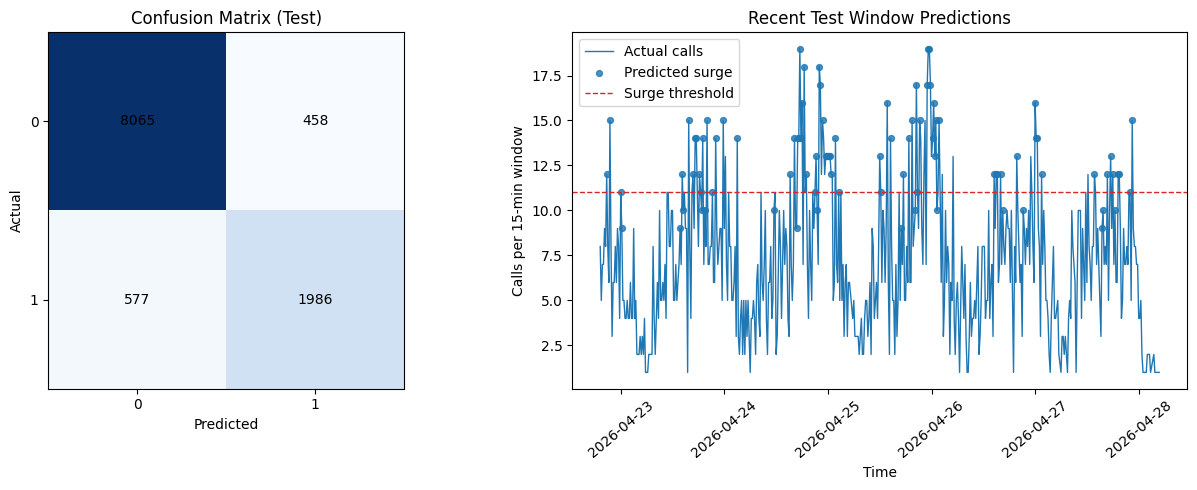

In [9]:
main_test_pred = (main_test_prob >= main_threshold).astype(int)
cm = confusion_matrix(y_test, main_test_pred)
print("Random forest classification report on test split:")
print(classification_report(y_test, main_test_pred, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

test_frame = agg_model.loc[test_mask, ["time_bin", "total_calls", "is_surge"]].copy()
test_frame["surge_prob"] = main_test_prob
test_frame["pred_surge"] = main_test_pred
plot_points = test_frame.tail(500).copy()

axes[1].plot(
    plot_points["time_bin"],
    plot_points["total_calls"],
    label="Actual calls",
    linewidth=1.0,
)
axes[1].scatter(
    plot_points.loc[plot_points["pred_surge"] == 1, "time_bin"],
    plot_points.loc[plot_points["pred_surge"] == 1, "total_calls"],
    s=18,
    label="Predicted surge",
    alpha=0.8,
)
axes[1].axhline(
    surge_threshold,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label="Surge threshold",
)
axes[1].set_title("Recent Test Window Predictions")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Calls per 15-min window")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

,feature,importance
0,unique_call_types,0.651299
1,rolling_calls_mean_4,0.094054
2,rolling_calls_mean_12,0.066553
3,hour,0.060788
4,lag_calls_1,0.034119
5,lag_calls_2,0.029165
6,lag_calls_4,0.017415
7,rolling_calls_std_12,0.011299
8,lag_calls_8,0.010528
9,lag_calls_12,0.004097


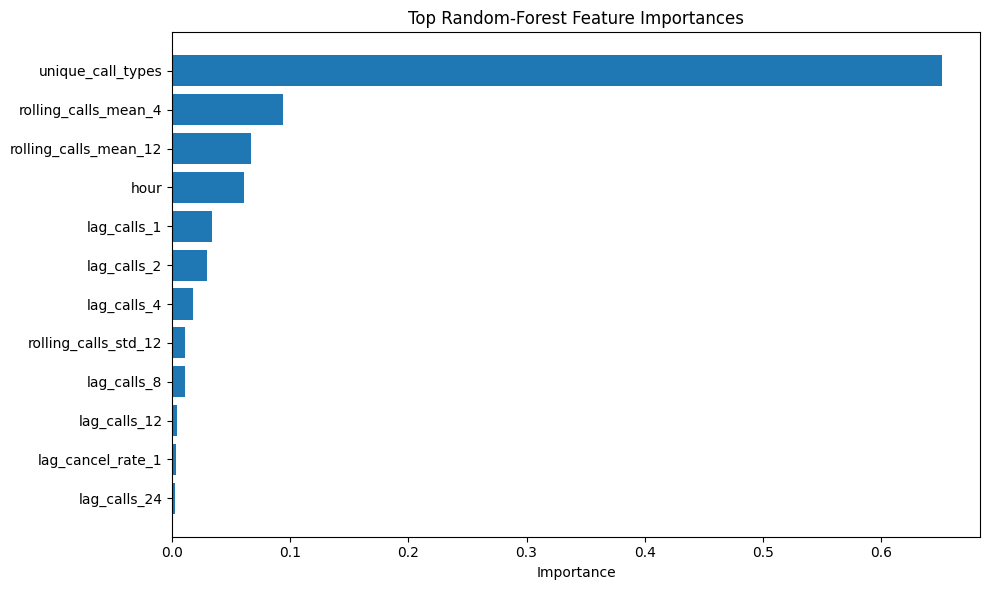

In [10]:
rf = main_model.named_steps["model"]
ohe = main_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(["day_of_week"]))
all_feature_names = numeric_cols + cat_feature_names

importance = (
    pd.DataFrame({"feature": all_feature_names, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(15))

plt.figure(figsize=(10, 6))
top_imp = importance.head(12).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top Random-Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Next improvements

1. Add walk-forward validation across multiple folds instead of one fixed split.
2. Compare fixed operational thresholds to quantile-based surge definitions.
3. Add calibration analysis if probabilities will be used directly for staffing alerts.